<center><img src="https://github.com/hse-ds/iad-applied-ds/blob/master/2021/hw/hw1/img/logo_hse.png?raw=1" width="1000"></center>

<h1><center>Прикладные задачи анализа данных</center></h1>
<h2><center>Домашнее задание 2: deep learning для обработки звука</center></h2>

# Введение

В этом задании Вы поработаете и разберетесь в деталях с форматами представления аудиоданных в задачах глубинного обучения, а так же напишете несколько моделей для классификации аудиозаписей.

В процессе выполнения Вы познакомитесь:
* С алгоритмом построения Мел-спектрограммы
* Рекуррентными и сверточными классификаторами аудиоданных
* Алгоритмом аугментации аудиоданных SpecAugment

In [1]:
# !pip install torch==1.8.0 torchaudio==0.8.0 numpy==1.20.0
!pip install -q torch torchaudio numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.2 MB/s eta 0:00:00


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torchaudio
from IPython import display
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

%matplotlib inline

# assert torch.__version__.startswith("1.8.0")
# assert torchaudio.__version__ == "0.8.0"

device = "cuda:0"

# Классификация аудиозаписей.

В этом домашнем задании Вам предстоит классифицировать аудиозаписи из датасета [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html).

Данный датасет состоит из 8732 записей, разбитых на train/val/test датасеты.

![image](https://paperswithcode.com/media/datasets/UrbanSound8K-0000003722-02faef06.jpg)

Каждая аудиозапись содержит запись шума города и принадлежит одному из 10 классов:

`[air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music]`


## Задание 1 (1 балл). Знакомство с данными.

- Скачайте датасет с [диска](https://disk.yandex.ru/d/LXmjlqdXsgseoQ) c и распакуйте в папку `./data`.
- Положите разархивированные данные рядом с юпитерской тетрадкой.

In [3]:
if not os.path.exists("data/"):
    link = 'https://disk.yandex.ru/d/LXmjlqdXsgseoQ' # Можно перейти по ссылке и скачать вручную

    import requests
    url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={link}"
    response = requests.get(url)
    download_url = response.json()["href"]

    with open("data.zip", "wb") as file:
        download_response = requests.get(download_url, stream=True)
        for chunk in download_response.iter_content(chunk_size=1024):
            if chunk:
                file.write(chunk)
                file.flush()

    ! unzip data.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/data/1677.wav      
  inflating: data/data/1678.wav      
  inflating: data/data/1679.wav      
  inflating: data/data/168.wav       
  inflating: data/data/1680.wav      
  inflating: data/data/1681.wav      
  inflating: data/data/1686.wav      
  inflating: data/data/1687.wav      
  inflating: data/data/1688.wav      
  inflating: data/data/1689.wav      
  inflating: data/data/1690.wav      
  inflating: data/data/1695.wav      
  inflating: data/data/1697.wav      
  inflating: data/data/1699.wav      
  inflating: data/data/17.wav        
  inflating: data/data/170.wav       
  inflating: data/data/1701.wav      
  inflating: data/data/1702.wav      
  inflating: data/data/1703.wav      
  inflating: data/data/1704.wav      
  inflating: data/data/1705.wav      
  inflating: data/data/1706.wav      
  inflating: data/data/1708.wav      
  inflating: data/data/1709.wav      
  inflating: data/data/171.wav       

- Напишите `AudioDataset` класс, который будет принимать путь к файлам `train_part.csv` и `val_part.csv` и возращать тройки объектов `(x, y, len)`, где `x` - аудиозапись, `y` - класс аудиозаписи, `len` - длина аудиозаписи. Аудиозаписи **не должны постоянно храниться в RAM**, подгрузку _wav_ файлов надо сделать при запросе через `__getitem__` метод. Кроме того, надо сделать паддинг аудиозаписи - если она короче чем `pad_size` параметр, надо дополнять ее нулями.

- С помощью функции `display.Audio` проиграйте в ноутбуке пару аудиозаписей.

In [4]:
# классы данных
classes = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music",
]

In [5]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int = 384000,
        sr: int = 44100,
    ):
        self.csv: pd.DataFrame = pd.read_csv(path_to_csv)[["ID", "Class"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size

        self.sr = sr

        self.class_to_idx = {classes[i]: i for i in range(10)}

    def __getitem__(self, index: int):
        ### YOUR CODE IS HERE ######
        entry = self.csv.iloc[index]
        class_idx = self.class_to_idx[entry.Class]

        wav, sr = torchaudio.load(f"{self.path_to_folder}/{entry.ID}.wav")

        assert sr == self.sr

        match wav.shape:
            case (1, wav_orig_len):
                wav.squeeze_(0)
                missing_len = self.pad_size - wav_orig_len
                if missing_len > 0:
                    wav = nn.functional.pad(input=wav, pad=(0, missing_len), mode="constant", value=0)
            case _:
                raise ValueError(f"Unknown shape {wav.shape}")

        return {
            "x": wav,
            "y": class_idx,
            "len": wav_orig_len,
        }

    def __len__(self):
        return self.csv.shape[0]

In [6]:
# создадим датасеты
train_dataset = AudioDataset("./data/train_part.csv", "./data/data")
val_dataset = AudioDataset("./data/val_part.csv", "./data/data")

In [7]:
# проверим размеры датасетов
assert len(train_dataset) == 4500
assert len(val_dataset) == 935

In [8]:
# проверим возращаемые значения __getitem__
item = train_dataset.__getitem__(0)

assert item["x"].shape == (384000,)
assert item["y"] == 0
assert item["len"] == 176400

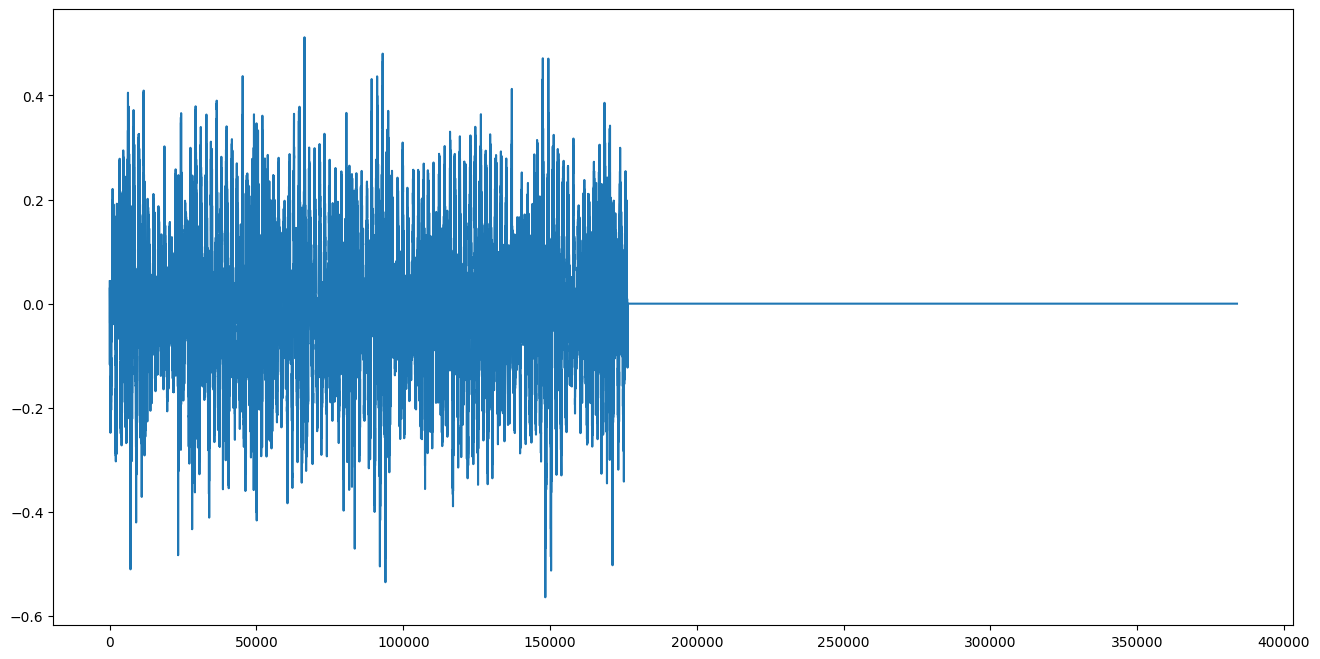

In [ ]:
# нарисуем и проиграем аудиозаписить
item = train_dataset.__getitem__(0)
plt.figure(figsize=(16, 8))
plt.plot(item["x"])

display.Audio(item["x"], rate=train_dataset.sr)

In [9]:
# создадим даталоадеры
train_dataloader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, pin_memory=True, drop_last=True
)
val_dataloader = DataLoader(val_dataset, batch_size=32, pin_memory=True)

## Задание 2. Рекуррентная сеть для классификации аудиозаписей по сырому сигналу (2 балла)

По своей сути аудиозапись является ни чем иным, как временным рядом - замеры микрофона делаются через равные промежутки времени и хранятся в виде последовательности.

Как известно, рекуррентные сети отлично подходят для работы с различными последовательностями, в том числе и с временными рядами.

Обучим простую реккурентную сеть для классификации аудиозаписей.

1. Разбейте аудизаписить на окошки размером `1024` с шагом `256`. Для этих целей отлично подойдет метод `torch.Tensor.unfold`.
1. Применим к каждому получившемуся окну аудиосигнала полносвязную сеть с активациями `ReLU` и  внутренними размерностям `(1024 -> 256 -> 64 -> 16)`.
2. По получившимся последовательностям пройдемся двунаправленой (`bidirectional=True`) LSTM с двумя слоями (`layers=2`).
3. Склеим c помощью `torch.cat` последние `hidden_state` для каждого слоя и применим к ним полносвязную сеть `(2 * hidden_size * num_layers -> 256 -> 10)` с активацией `ReLU`.

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-applied-ds/2020-2023/2022/hw/hw2/imgs/rnn_raw.png" height="500">
</center>

*Совет*: для убыстрения обучения имеет смысл в полносвязные сети добавить `BatchNorm`.

In [10]:
class FirstMLP(nn.Module):
    def __init__(self, input_size: int):
        super(FirstMLP, self).__init__()

        self.l1 = nn.Linear(in_features=input_size, out_features=input_size >> 2)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(in_features=self.l1.out_features, out_features=self.l1.out_features >> 2)
        self.a2 = nn.ReLU()
        self.bn2 = nn.BatchNorm1d(num_features=self.l2.out_features)
        self.l3 = nn.Linear(in_features=self.l2.out_features, out_features=self.l2.out_features >> 2)

        self.input_size = self.l1.in_features
        self.output_size = self.l3.out_features

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.l3(
            self.bn2(self.a2(self.l2(
                self.a1(self.l1(x))
            )).transpose(1, 2)).transpose(1, 2)
        )

class FinalMLP(nn.Module):
    def __init__(self, input_size: int, output_size: int, hidden_size: int = 256):
        super(FinalMLP, self).__init__()

        self.l1 = nn.Linear(in_features=input_size, out_features=hidden_size)
        self.a1 = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(num_features=self.l1.out_features)
        self.l2 = nn.Linear(in_features=self.l1.out_features, out_features=output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.l2(
            self.bn1(self.a1(self.l1(x)))
        )

class RecurrentRawAudioClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        self.first_mlp = FirstMLP(input_size=window_length)

        self.rnn = nn.LSTM(
            input_size=self.first_mlp.output_size,
            hidden_size=hidden,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
        )

        self.final_mlp = FinalMLP(input_size=2 * hidden * num_layers, output_size=num_classes)

    def forward(self, x: torch.Tensor, lens) -> torch.Tensor:
        # разбейте сигнал на окна
        batch_size, _ = x.shape
        # batch_windows.shape == (B, NUM WINDOWS, 1024)
        batch_windows = x.unfold(dimension=1, size=self.window_length, step=self.hop_length)

        # примените к каждому окну полносвязную сеть
        # batch_windows_feautures.shape == (B, NUM WINDOWS, 16)
        batch_windows_feautures = self.first_mlp(batch_windows)

        # примените к получившемся последовательностям LSTM и возьмите hidden state
        _, (final_hidden_state, _) = self.rnn(batch_windows_feautures)

        # склейте hidden_state по слоям
        # hidden_flattened.shape = (B, 2 * hidden_size * num_layers)
        hidden_flattened = final_hidden_state.permute(1, 0, 2).reshape(batch_size, -1)

        # примените полносвязную сеть и получим логиты классов
        return self.final_mlp(hidden_flattened)

Обучим получившуюся модель.

In [11]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    augmentation=None,
    num_epochs=10,
    device="cuda:0",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            # применяем преобразование входных данных
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            # примеменяем к логмелспектрограмме аугментацию
            if augmentation:
                x, lens = augmentation(x, lens)

            probs = model(x, lens)
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            # считаем точность предсказания
            pred_cls = probs.argmax(dim=-1)
            train_accuracies.append((pred_cls == y).float().mean().item())

            iter_i += 1

            # раз в verbose_num_iters визуализируем наши лоссы и семплы
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)

                print(f"Epoch {epoch}")

                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)

                plt.show()

    model.eval()

In [ ]:
# создадим объекты модели и оптимизатор
rnn_raw = RecurrentRawAudioClassifier()
rnn_raw.to(device)
optim = torch.optim.Adam(rnn_raw.parameters(), lr=3e-4)

Epoch 9


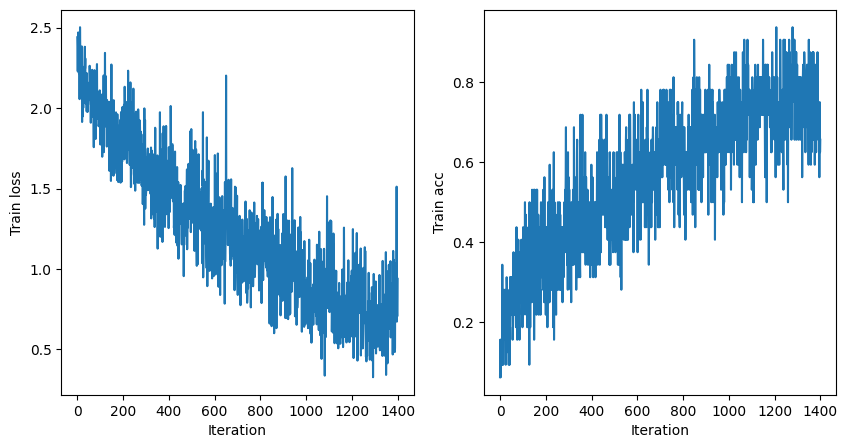

In [ ]:
# обучим модель
train_audio_clfr(rnn_raw, optim, train_dataloader, train_dataset.sr)

Посчитаем метрики на валидационном датасете.

In [17]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    print(f"Val accuracy: {np.mean([p[0] == p[1] for p in pred_true_pairs])}")

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)

Val accuracy: 0.3700534759358289


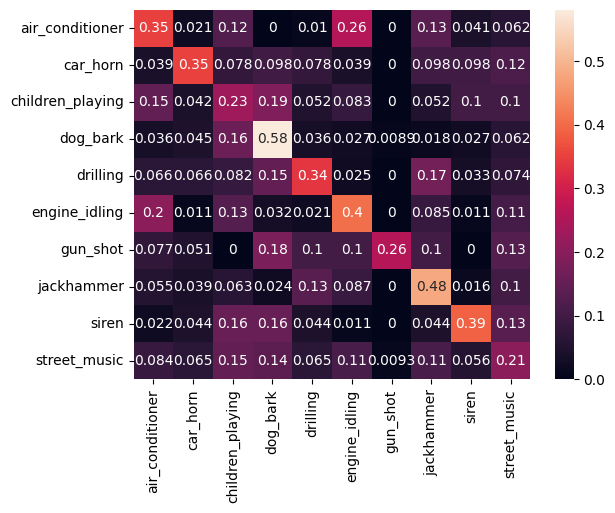

In [ ]:
plot_confusion_matrix(rnn_raw, val_dataloader, train_dataset.sr, device)

*Вопрос* : Сильно ли отличается качество модели на тренировочной и валидационной выборке? Если да, то как думаете, в чем причина?

Построим графики распределения классов для train и val выборок:

In [ ]:
from collections import defaultdict

def count_classes(dataset: AudioDataset) -> dict[str, int]:
    cnt = defaultdict(int)
    for elem in dataset:
        cnt[classes[elem["y"]]] += 1

    return cnt

def plot_classes_distribution(dataset: AudioDataset):
    classes_distribution = count_classes(dataset)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 6), width_ratios=(5, 2))
    sn.barplot(ax=ax1, x=classes_distribution.keys(), y=classes_distribution.values(), width=0.6)
    ax2.pie(x=list(classes_distribution.values()), labels=list(classes_distribution.keys()))

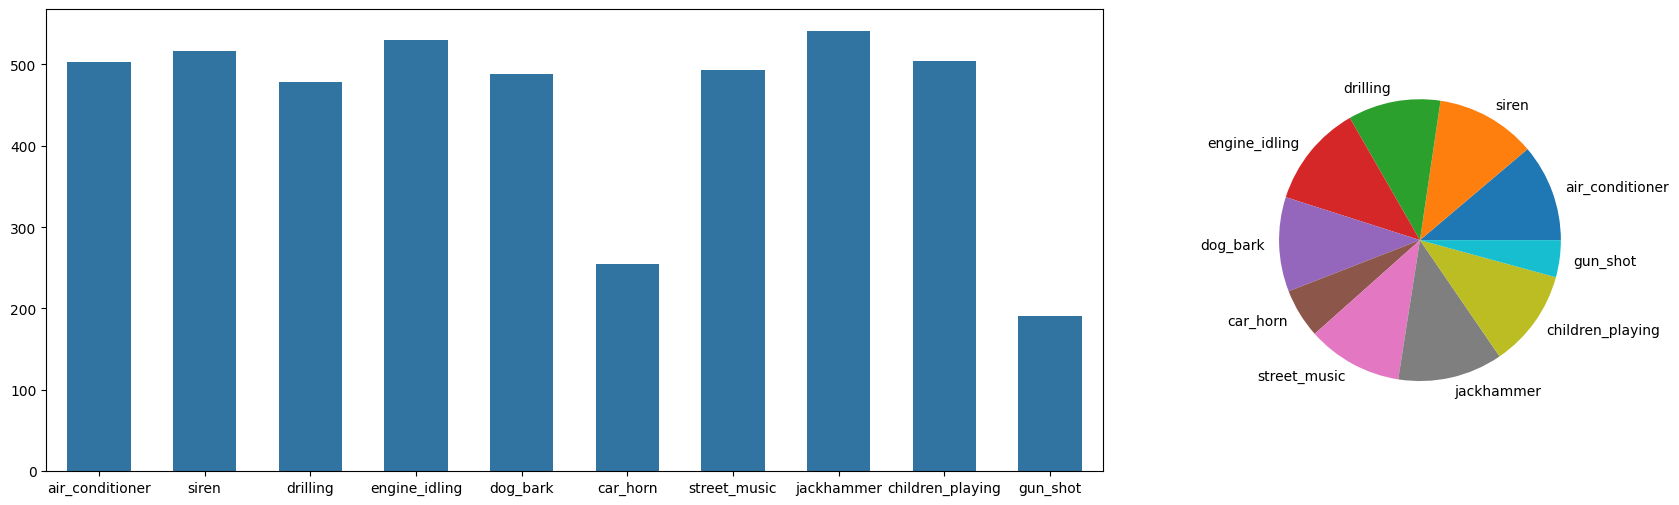

In [ ]:
plot_classes_distribution(train_dataset)

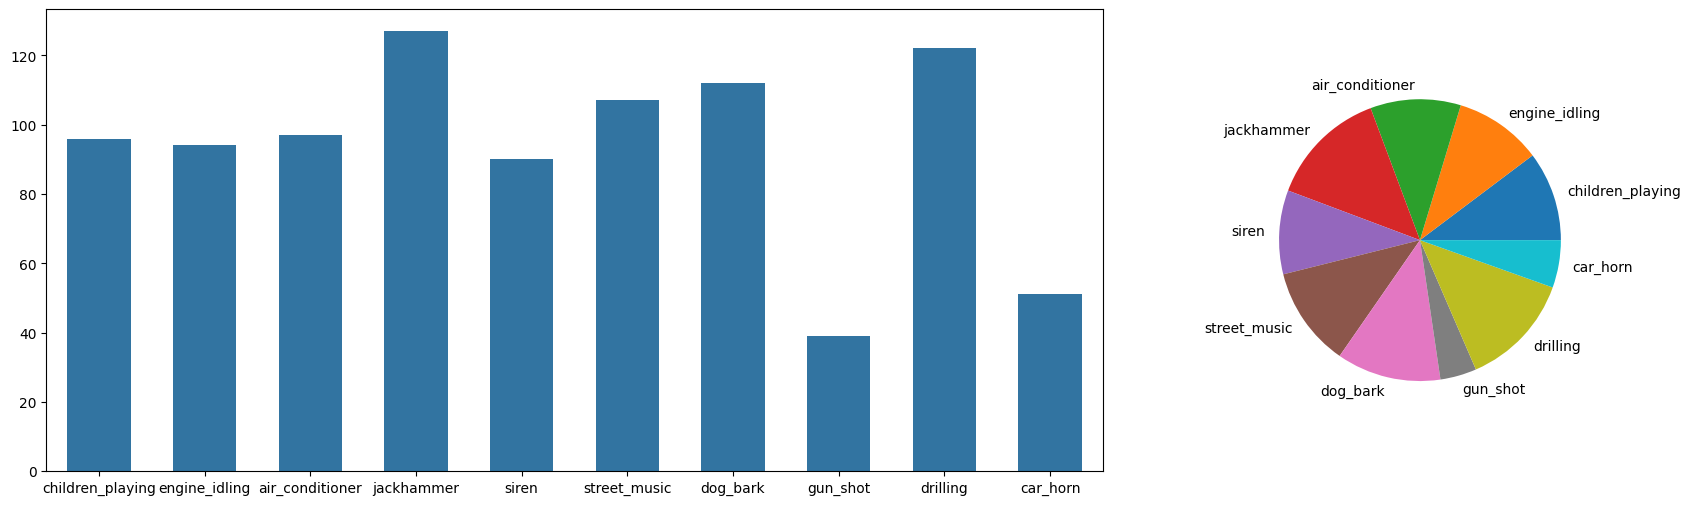

In [ ]:
plot_classes_distribution(val_dataset)

Судя по графикам, распределения классов в трейне и на валидации примерно одинаковы

Из heatmap с confusion matrix видно, что:
- drilling достаточно часто (половина от правильных детекций как ground truth класс drilling) идентифицируется как jackhammer. Возможно, качество звуков низкое и в таком качестве звуки дрели и отбойного молотка похожи
- air_conditioner достаточно часто идентифицируется как engine_idling (возможно звук вентилятора в системе охлаждения слышен во время простоя двинателя и похож на звук вентилятора кондиционера). Аналогично, быть может, есть схожесть звуков из-за плохого качества записей (или низкого качества данных на этапе обработки моделью)
- children_playing и gun_shot достаточно часто идентифицирются как dog_bark. Возможно, в данном формате (без каких-либо предобработок) они действительно слабо различимы
- Модель практически не отличает street_music от остальных типов звука

## Задание 3. Построение Мел-cпектрограмм. (2 балла)

Сырой сигнал очень чувствителен ко многим факторам - увеличение/уменьшение громкости, внешние шумы, сменение тембра говорящего очень резко меняют сырой сигнал. Это влияет и на качество глубоких сетей, обученных на сыром аудиосигнале.

Для построения надежных и устойчивых к переобучению моделей используют другое представление аудиоданных - спектрограммы, в том числе Мел-спектрограмму.

Идея её построения заключается в следующем:
1. Сигнал разбивается на временные интервалы (с пересечениями)
2. К каждому временному интервалу применяется фильтр (как правило косинусоидальный)
3. К профильтрованному сигналу применяется дискретное преобразование Фурье и вычисляются спектральные признаки сигнала.
4. Спектральные признаки с помощью логарифмического преобразования приводятся в Мел-шкалу.

<center>
<img src="https://antkillerfarm.github.io/images/img2/Spectrogram_5.png" height="550">
</center>

В этом задании мы сами шаг за шагом напишем алгоритм построения мелспектрограммы и сравнимся с референсной функцией из `torchaudio`.

In [27]:
from torchaudio.transforms import MelSpectrogram


# референсная функця
def compute_log_melspectrogram_reference(wav_batch, lens, sr, device="cpu"):
    featurizer = MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        win_length=1024,
        hop_length=256,
        n_mels=64,
        center=False,
    ).to(device)

    return torch.log(featurizer(wav_batch).clamp(1e-5)), lens // 256

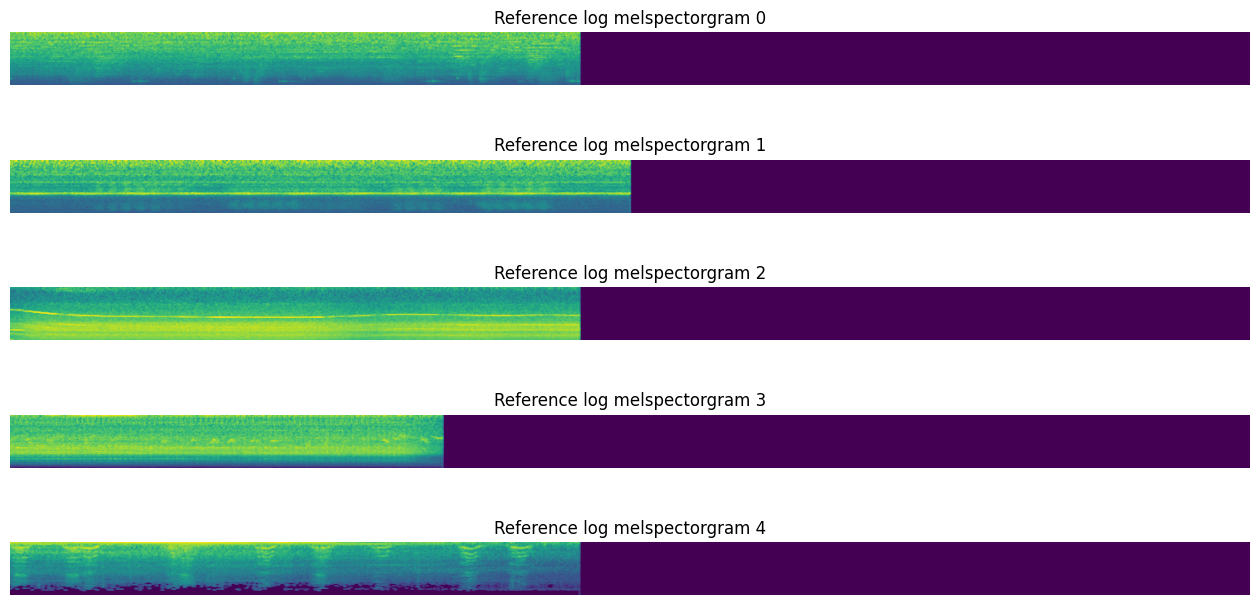

In [ ]:
# возьмем случайный батч
for batch in train_dataloader:
    break

wav_batch = batch["x"]
lens = batch["len"]

# посчитаем лог мелспектрограммы
log_melspect, lens = compute_log_melspectrogram_reference(
    wav_batch, lens, train_dataset.sr
)

# нарисуем получившиеся референсные значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Reference log melspectorgram {i}")
    axes[i].imshow(log_melspect[i].numpy())

Теперь сделаем то же самое сами.

In [ ]:
sr = train_dataset.sr
n_fft = 1024
win_length = 1024
hop_length = 256
n_mels = 64


Для начала с помощью метода `unfold` разделим аудиосигнал на окна размера `win_lenght` через промежутки `hop_lenght`.

In [ ]:
windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length)
assert windows.shape == (32, 1497, 1024)

Нарисуем и проиграем сигнал из одного окна.

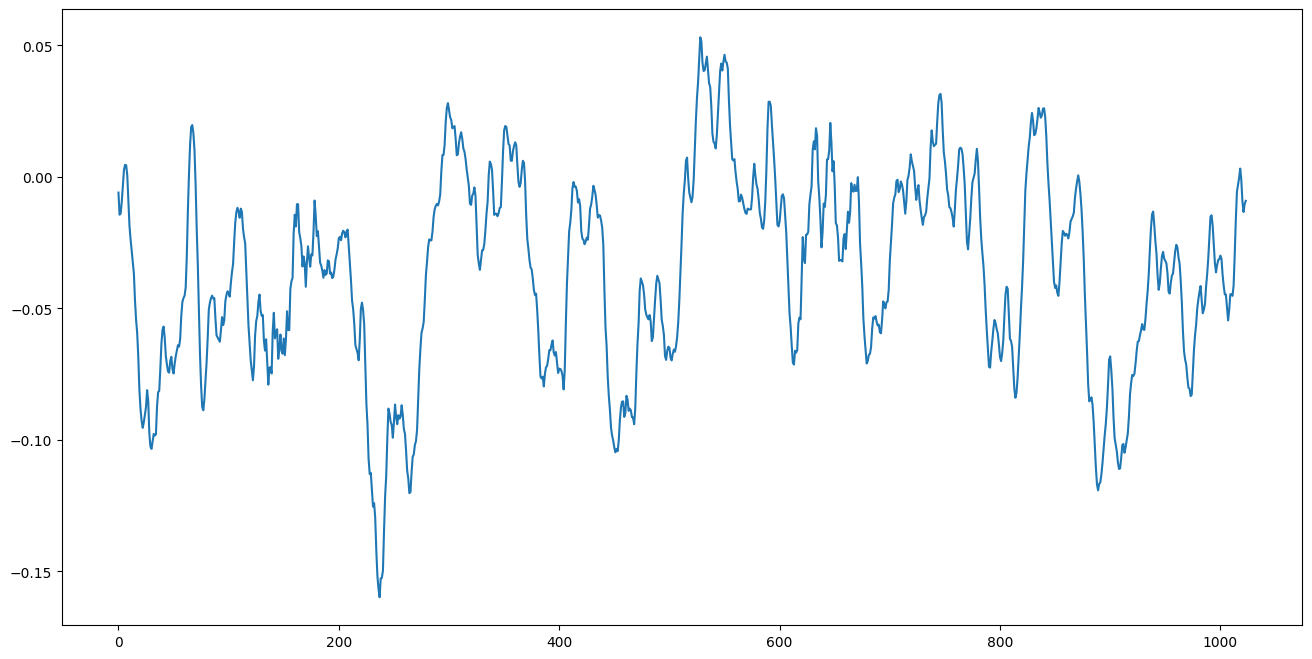

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(windows[0, 0])

display.Audio(windows[0, 0], rate=train_dataset.sr)

Теперь нам надо применить косинуисальный фильтр к сигналу из окна. Для этого с помощью `torch.hann_window` создадим косинусоидальный фильтр и умножим его поэлементно на все окна.

In [ ]:
filter = torch.hann_window(window_length=win_length)
windows_with_applied_filter = windows * filter[None, None, :]

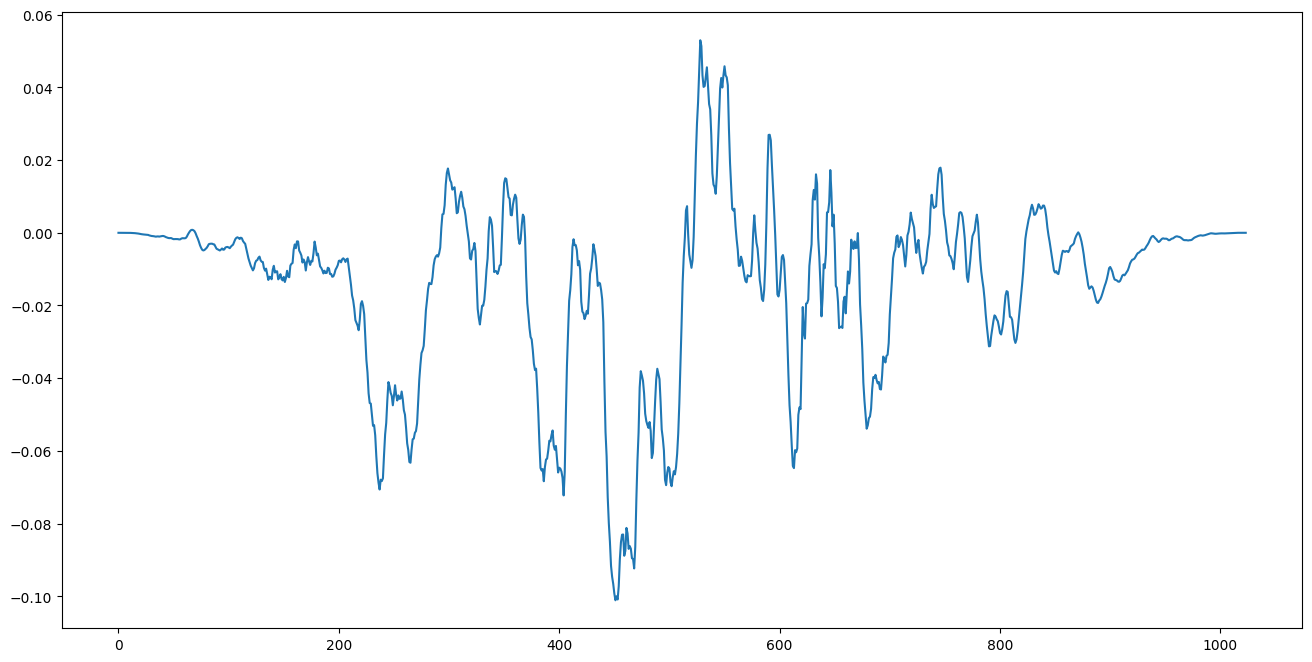

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(windows_with_applied_filter[0, 0])

display.Audio(windows_with_applied_filter[0, 0], rate=train_dataset.sr)

С помощью `torch.fft.fft` примените дискретное преобразование фурье к каждому окну и возьмите первые `n_fft // 2 + 1` компоненты.

Дальше с помощью возведения элементов тензора в квадрат и `torch.abs()` получите магнитуды.

In [ ]:
fft_features = torch.fft.fft(windows_with_applied_filter, dim=2)[:,:,:n_fft // 2 + 1]
fft_magnitudes = torch.abs(fft_features**2)
assert fft_magnitudes.shape == (32, 1497, 513)

Через `torchaudio.transforms.MelScale` создайте класс для перевода магнитуд в Мел-шкалу.

In [ ]:
melscale = torchaudio.transforms.MelScale(
    n_mels=n_mels,
    sample_rate=sr,
    n_stft=fft_magnitudes.shape[2],
)

Нелинейное преобразование для перевода в Мел-шкалу выглядит следующим образом.

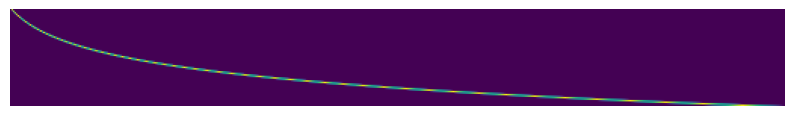

In [ ]:
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.imshow(melscale.fb.numpy().transpose())
plt.show()

Примените Мел-шкалу к магнитудам.

In [ ]:
mel_spectrogram = melscale(fft_magnitudes.transpose(2, 1))
assert mel_spectrogram.shape == (32, 64, 1497)

Сделайте обрезку значений по `1e-5` и примените `torch.log` для получения логарифмированной Мел-спектрограммы.

In [ ]:
logmel_spectrogram = mel_spectrogram.clamp(min=1e-5).log_()
assert logmel_spectrogram.shape == (32, 64, 1497)

Полученные логарифмированные Мел-Спектрограммы должны совпадать с референсными.

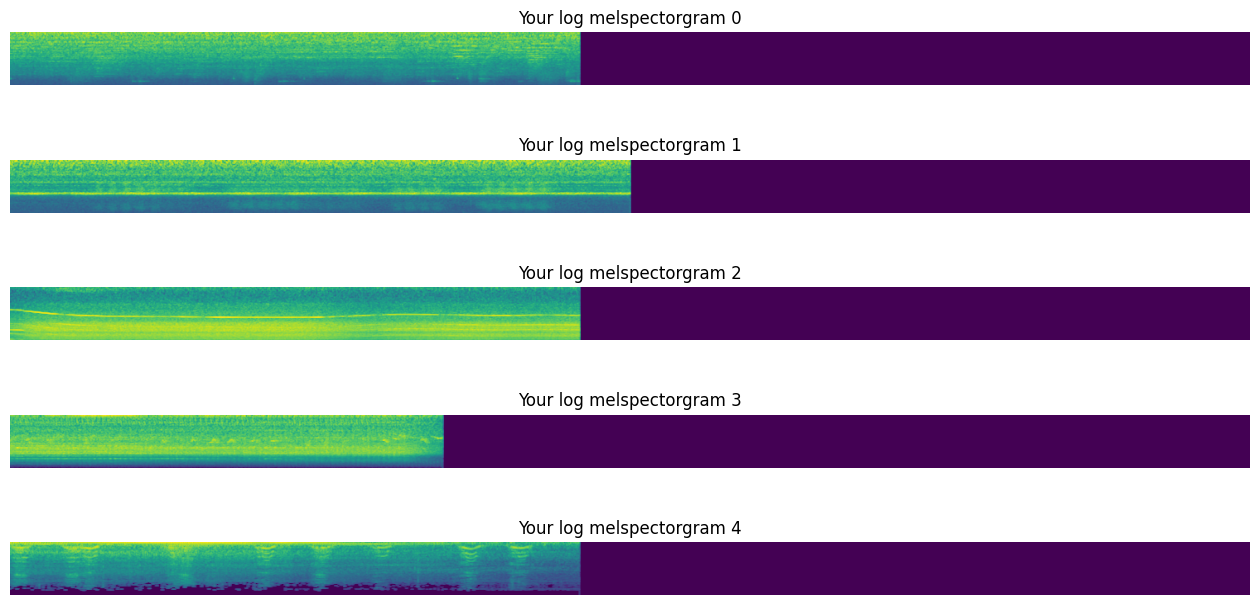

In [ ]:
# нарисуем получившиеся значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Your log melspectorgram {i}")
    axes[i].imshow(logmel_spectrogram[i].numpy())

Теперь оформим эту логику в функцию.

In [12]:
# ваша реализация
def compute_log_melspectrogram(wav_batch: torch.Tensor, lens, sr, device="cpu"):
    ### YOUR CODE IS HERE ######

    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 64

    windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length).to(device, non_blocking=True)

    filter = torch.hann_window(window_length=win_length, device=device)
    windows_with_applied_filter = windows * filter[None, None, :]

    fft_features = torch.fft.fft(windows_with_applied_filter, dim=2)[:,:,:n_fft // 2 + 1]
    fft_magnitudes = torch.abs(fft_features**2)

    melscale = torchaudio.transforms.MelScale(
        n_mels=n_mels,
        sample_rate=sr,
        n_stft=fft_magnitudes.shape[2],
    ).to(device=device)

    mel_spectrogram = melscale(fft_magnitudes.transpose(2, 1))

    logmel_spectrogram = mel_spectrogram.clamp(min=1e-5).log_()

    return logmel_spectrogram, lens // 256
    ### THE END OF YOUR CODE ###

Финальная проверка.

In [ ]:
assert torch.allclose(
    compute_log_melspectrogram_reference(wav_batch, lens, train_dataset.sr)[0],
    compute_log_melspectrogram(wav_batch, lens, train_dataset.sr)[0],
    atol=1e-5,
)

## Задание 4. Рекуррентная сеть для классификации аудиозаписей по логарифмированным Мел-спектрограммам (1 балл)

Измените реализацию рекуррентной сети из задания 2, таким образом, чтобы она вместо сырого сигнала смогла принимать логарифмированные Мел-спетрограммы:
1. Уберите шаги 1-2
2. Сделайте вход LSTM равным 64

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-applied-ds/2020-2023/2022/hw/hw2/imgs/rnn_mel.png" height="500">
</center>

**За реализацию архитектуры дается 0.5 балла.**

In [13]:
class RecurrentMelSpectClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        ### YOUR CODE IS HERE ######
        self.rnn = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
        )

        self.final_mlp = FinalMLP(input_size=2 * hidden * num_layers, output_size=num_classes)
        ### THE END OF YOUR CODE ###

    def forward(self, x: torch.Tensor, lens):
        ### YOUR CODE IS HERE ######
        batch_size, _, _ = x.shape
        assert x.get_device() == 0, f"x.device = {x.device}"
        _, (final_hidden_state, _) = self.rnn(x.transpose(1, 2))
        hidden_flattened = final_hidden_state.permute(1, 0, 2).reshape(batch_size, -1)
        return self.final_mlp(hidden_flattened)
        ### THE END OF YOUR CODE ###

In [14]:
rnn_mel = RecurrentMelSpectClassifier()
rnn_mel.to(device)

optim = torch.optim.Adam(rnn_mel.parameters(), lr=3e-4)

Epoch 9


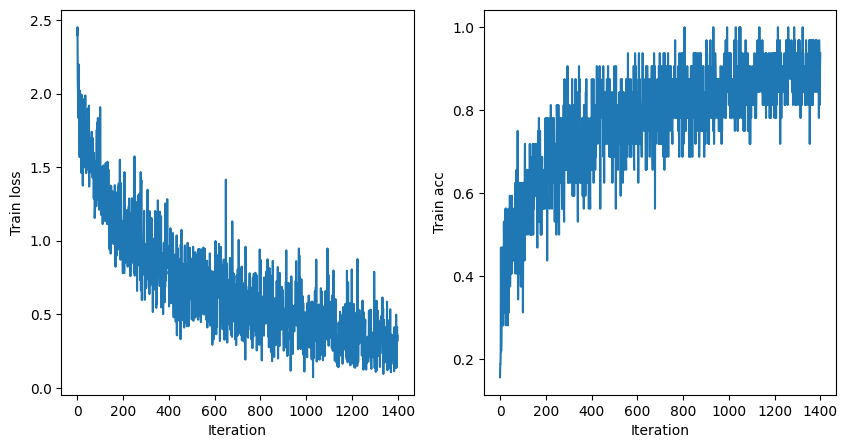

In [15]:
train_audio_clfr(
    rnn_mel,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
)

Посчитаем метрики на валидационном датасете.

**Задание: для получения 0.5 балла сделайте подбор гиперпараметров и добейтесь accuracy модели выше 0.8 на валидационном датасете.**

Val accuracy: 0.7946524064171123


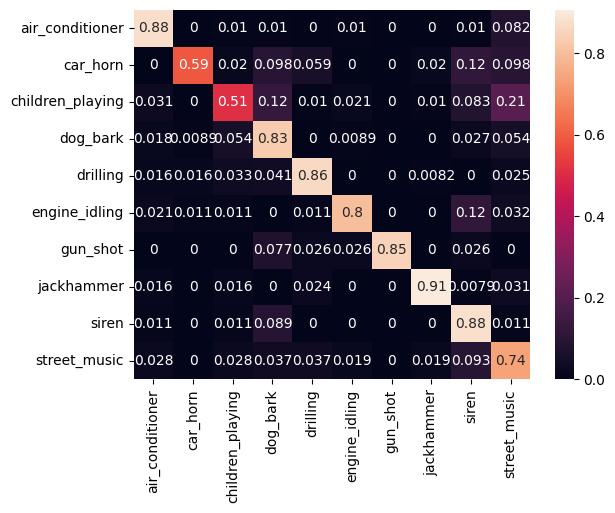

In [18]:
plot_confusion_matrix(
    rnn_mel,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Задание 5. Cверточная сеть для классификации аудиозаписей по мелспектрограммам. (2 балла)

Легко заметить, что мелспектрограммы имеют четко выраженные паттерны - если приноровиться, то даже человек, посмотрев на мелспектрограмму, сможет _визуально_ проклассифицировать объект.

Это позволяет свести задачу классификации аудиозаписей к задаче классификации картинок.

Реализуем такую сверточную сеть:

* 2x (Conv2d 3x3 @ 16, BatchNorm2d, ReLU)
* MaxPoll 2x2
* 2x (Conv2d 3x3 @ 32, BatchNorm2d, ReLU)
* MaxPoll 2x2
* 2x (Conv2d 3x3 @ 64, BatchNorm2d, ReLU)
* MaxPoll 2x2
* (Conv2d 3x3 @ 128, BatchNorm2d, ReLU)
* (Conv2d 2x2 @ 128, BatchNorm2d, ReLU)
* Global MaxPoll
* Fully Connected 128, ReLU
* Fully Connected 10

Совет: подобная архитектура была реализована в [**PANNs: Large-Scale Pretrained Audio Neural Networks for Audio Pattern Recognition**](https://arxiv.org/pdf/1912.10211.pdf), можете использовать эту статью как референс.


**За реализацию архитектуры дается 1.5 балла.**

In [22]:
class CNN10(nn.Module):
    def __init__(self, num_classes=10, hidden=16):
        super().__init__()

        ### YOUR CODE IS HERE ######

        def make_block(in_channels: int, out_channels: int):
            l1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3)
            bn1 = nn.BatchNorm2d(num_features=l1.out_channels)
            act1 = nn.ReLU()
            l2 = nn.Conv2d(in_channels=l1.out_channels, out_channels=out_channels, kernel_size=3)
            bn2 = nn.BatchNorm2d(num_features=l2.out_channels)
            act2 = nn.ReLU()
            return (
                l1,
                bn1,
                act1,
                l2,
                bn2,
                act2,
            )

        def make_final_block(in_channels: int, out_channels: int):
            l1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3)
            bn1 = nn.BatchNorm2d(num_features=l1.out_channels)
            act1 = nn.ReLU()
            l2 = nn.Conv2d(in_channels=l1.out_channels, out_channels=out_channels, kernel_size=2)
            bn2 = nn.BatchNorm2d(num_features=l2.out_channels)
            act2 = nn.ReLU()
            return (
                l1,
                bn1,
                act1,
                l2,
                bn2,
                act2,
            )

        self.cnn_backbone = nn.Sequential(
            *make_block(in_channels=1, out_channels=hidden),
            nn.MaxPool2d(kernel_size=2),
            *make_block(in_channels=hidden, out_channels=hidden << 1),
            nn.MaxPool2d(kernel_size=2),
            *make_block(in_channels=hidden << 1, out_channels=hidden << 2),
            nn.MaxPool2d(kernel_size=2),
            *make_final_block(in_channels=hidden << 2, out_channels=hidden << 3),
        )

        self.final_mlp = FinalMLP(input_size=hidden << 3, output_size=num_classes, hidden_size=hidden << 3)
        ### THE END OF YOUR CODE ###

    def forward(self, x: torch.Tensor, lens):
        z = self.cnn_backbone(x[:, None, :, :])
        z = torch.nn.functional.max_pool2d(z, kernel_size=z.size()[2:])[:, :, 0, 0]
        return self.final_mlp(z)

In [23]:
cnn = CNN10(hidden=32)
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 19


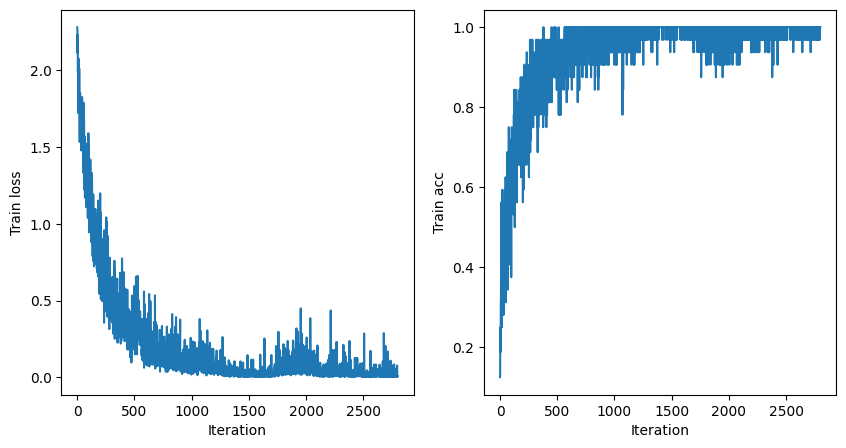

In [24]:
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    num_epochs=20,
)

**Задание: для получения 0.5 балла сделайте подбор гиперпараметров и добейтесь accuracy модели выше 0.85 на валидационном датасете.**

Val accuracy: 0.8695187165775401


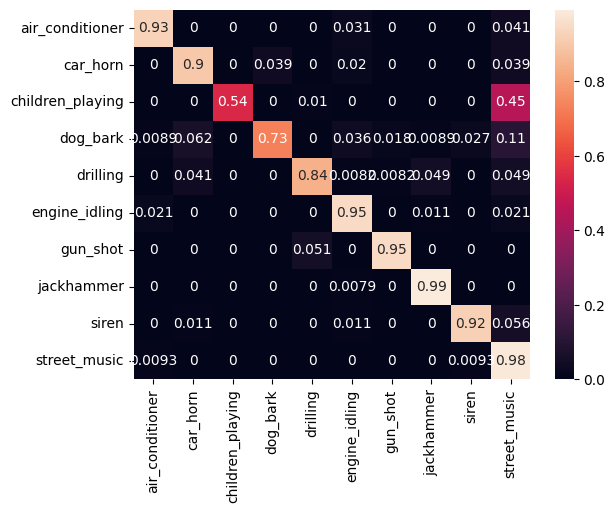

In [25]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Задание 6. Аугментация SpecAugment (2 балла)

Обычно датасеты с аудиозаписями довольно малы. Наш датасет тому пример - всего 4500 объектов в обучающей выборке. Обучение глубокий сетей с большим кол-вом параметров на таких датасетах часто ведет к переобучению и проседанию метрик на валидационном и тестовом датасетах.

Для борьбы с переобучением имеет смысл использовать аугментацию данных. Для мелспектрограмм была придумана аугментация под названием SpecAugment.

Смысл её очень прост - зануление спектрограммы по временным промежуткам и по мел-частотам:
1. Выбираются несколько временных промежутков ${[t^1_i, t^2_i]}$ и заполняют спектрограмму $s[t^1_i : t^2_i, :]$ значением $v$.

2. Выбираются несколько промежутков мелчастот ${[m^1_i, m^2_i]}$ и заполняют спектрограмму $s[:, m^1_i : m^2_i]$ значением $v$.

В качестве значения $v$ выбирают:
1. `'mean'`: среднее по спектрограмме
2. `'min'`: минимум по спектрограмме
3. `'max'`: максимум по спектрограмме
5. `v`: некоторая константа

Совет: описание аугментации можно найти здесь: [link](https://neurohive.io/ru/novosti/specaugment-novyj-metod-augmentacii-audiodannyh-ot-google-ai/), можете использовать эту ссылку как референс.

![specaugment](https://neurohive.io/wp-content/uploads/2019/04/image6.png)

В этом задании Вам предлагается реализовать аугментацию SpecAugment.

**За реализацию аугментации дается 1.5 балла.**


In [119]:
import random


class SpectAugment:
    def __init__(
        self,
        filling_value="mean",
        n_freq_masks=2,
        n_time_masks=2,
        max_freq=10,
        max_time=50,
    ):

        self.filling_value = filling_value
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
        self.max_freq = max_freq
        self.max_time = max_time

        self.filling_values_getter = SpectAugment.__determine_filling_value_getter(filling_value)

    def __call__(self, spect: torch.Tensor, lens: torch.Tensor):
        ### YOUR CODE IS HERE ######
        assert spect.dim() == 3
        assert lens.dim() == 1 and spect.shape[0] == lens.shape[0]

        spect = spect.detach().clone()

        filling_values = self.filling_values_getter(spect, lens)
        F = self.max_freq
        T = self.max_time
        n_freq_masks = self.n_freq_masks
        n_time_masks = self.n_time_masks

        for i in range(len(spect)):
            filling_value = filling_values[i]

            recording_max_frequency = spect.shape[1]
            recording_time_length = min(lens[i], spect.shape[2])

            for f in torch.randint(1, min(F, recording_max_frequency), (n_freq_masks,)):
                f0 = torch.randint(recording_max_frequency - f, (1,)).item()
                frequency_subspan = torch.arange(f0, f0 + f)
                spect[i, frequency_subspan, :recording_time_length] = filling_value

            for t in torch.randint(1, min(T, recording_time_length), (n_time_masks,)):
                t0 = torch.randint(recording_time_length - t, (1,)).item()
                time_subspan = torch.arange(t0, t0 + t)
                spect[i, :, time_subspan] = filling_values[i]

        return spect, lens
        ### THE END OF YOUR CODE ###

    @staticmethod
    def __determine_filling_value_getter(value):
        if isinstance(value, str):
            match value:
                case "mean":
                    return lambda x, lens: torch.tensor([x[i, :, :lens[i]].mean() for i in range(len(lens))])
                case "min":
                    return lambda x, lens: torch.tensor([x[i, :, :lens[i]].min() for i in range(len(lens))])
                case "max":
                    return lambda x, lens: torch.tensor([x[i, :, :lens[i]].max() for i in range(len(lens))])
                case _:
                    raise ValueError(f"Invalid filling mode {value}")

        assert not isinstance(value, torch.Tensor)
        assert not isinstance(value, np.ndarray)
        assert not isinstance(value, tuple)
        assert not isinstance(value, list)

        return lambda x, lens: torch.full((x.shape[0],), value)


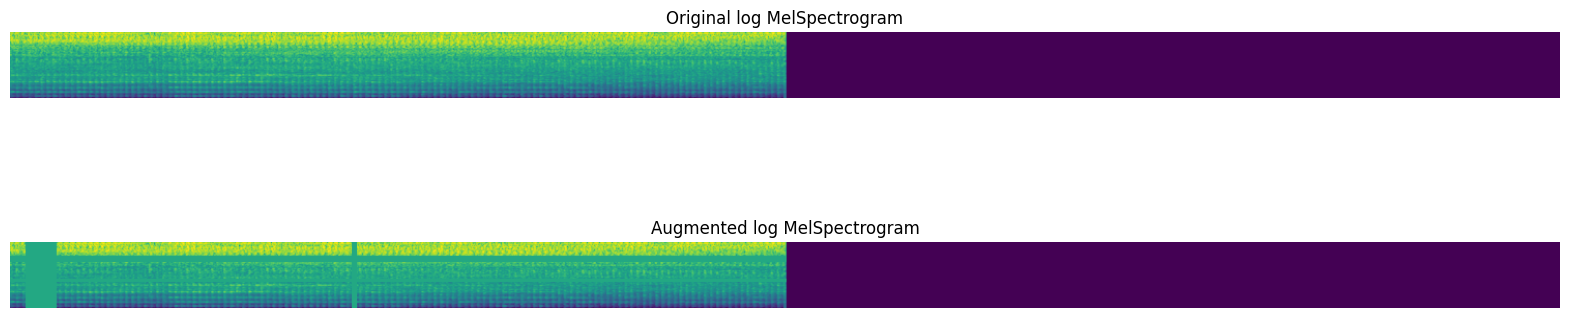

In [124]:
# применим аугментацию к данным
for batch in train_dataloader:
    break

x = batch["x"].to(device)
lens = batch["len"].to(device)
x_logmel, lens = compute_log_melspectrogram_reference(
    x, lens, sr=train_dataset.sr, device=device
)
x_logmel_augmented, lens = SpectAugment()(x_logmel, lens)

# нарисуем спектрограмму до и после аугментации
plt.figure(figsize=(20, 5))
plt.subplot(2, 1, 1)
plt.title("Original log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel[0].cpu().numpy())

plt.subplot(2, 1, 2)
plt.title("Augmented log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel_augmented[0].cpu().numpy())

plt.show()

In [125]:
cnn = CNN10(hidden=40)
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 21


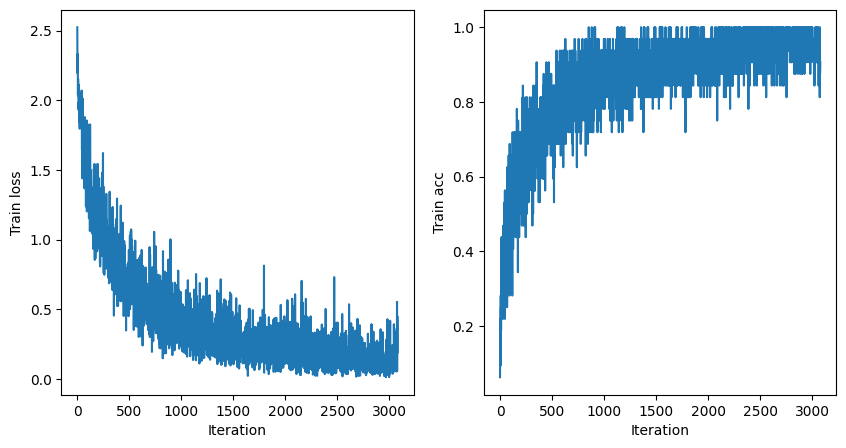

In [126]:
# обучим модель на данных с аугментациями
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    augmentation=SpectAugment(),
    num_epochs=22,
)

**Задание: для получения 0.5 балла сделайте подбор параметров аугментации и добейтесь accuracy модели выше 0.9 на валидационном датасете.**

Val accuracy: 0.8780748663101604


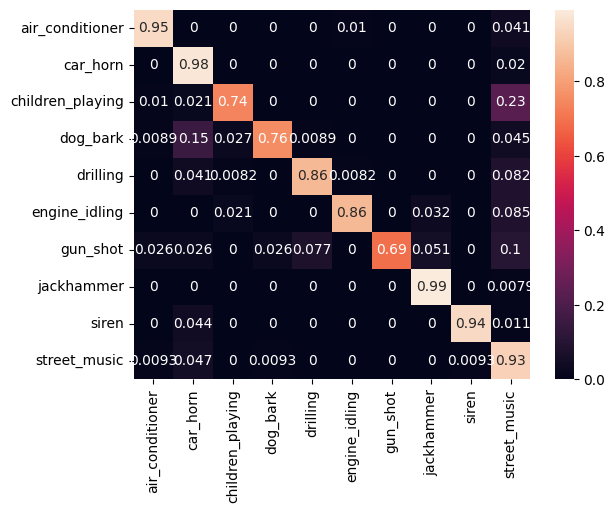

In [127]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)